Fichier utilisé : dvf_final_2020_2025.csv
Shape : (5828160, 22)


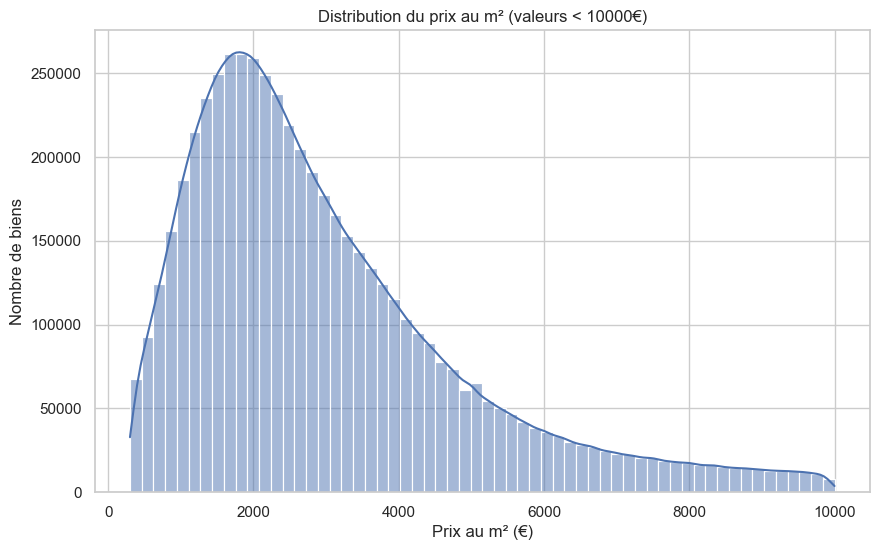

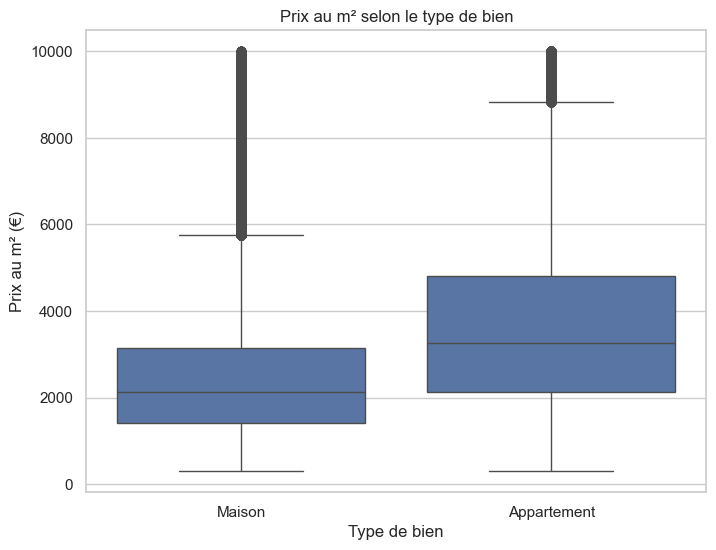

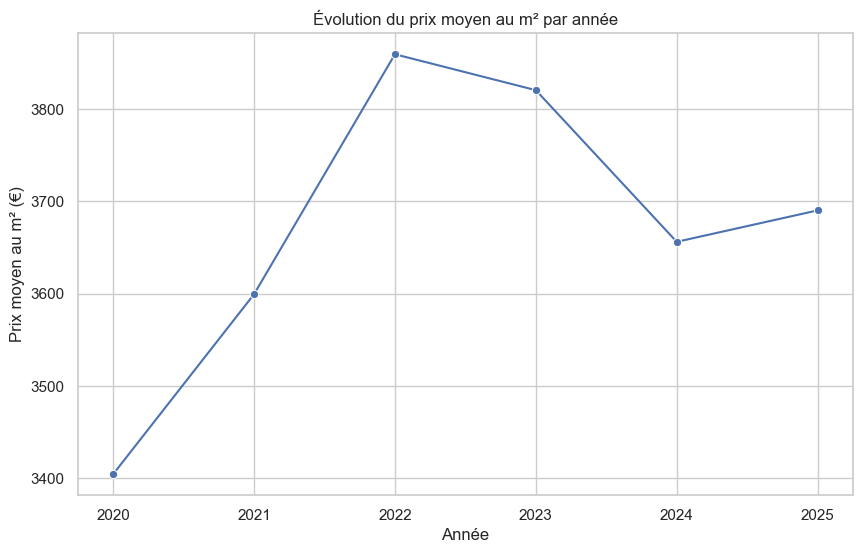

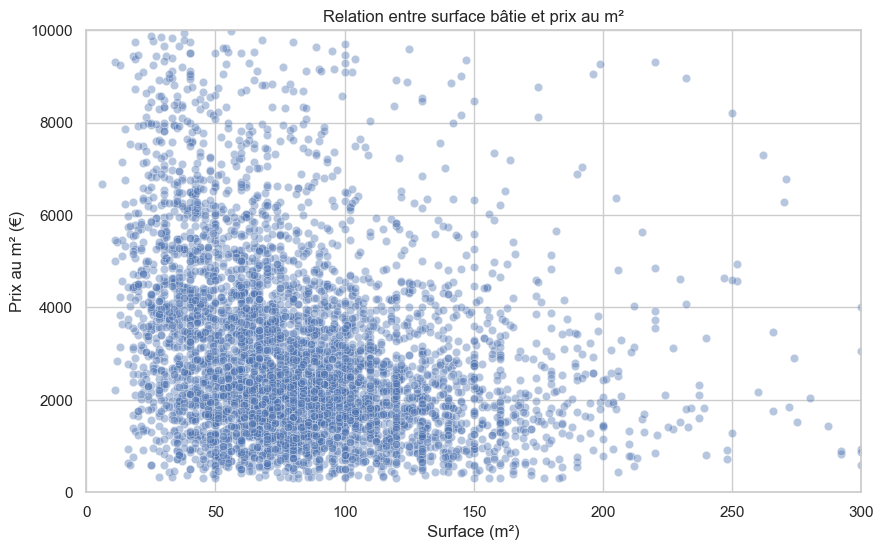

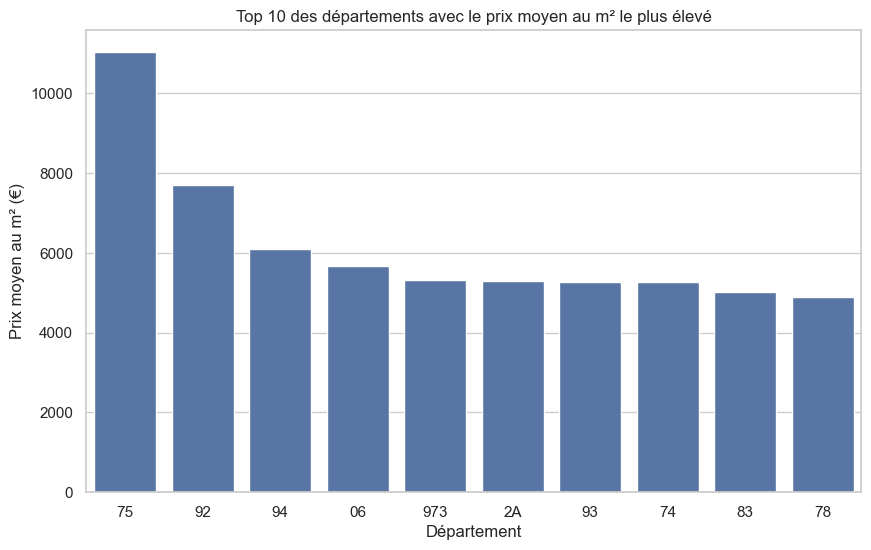

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ============================================================
# 1. CHARGEMENT DU DATASET
# ============================================================

# Détection automatique du fichier
fichier = None
for f in os.listdir():
    if "dvf_final_2020_2025" in f:
        fichier = f
        break

if fichier is None:
    raise FileNotFoundError("Fichier dvf_final_2020_2025 introuvable")

print("Fichier utilisé :", fichier)

df = pd.read_csv(fichier, low_memory=False)

print("Shape :", df.shape)

# Nettoyage minimal
df = df.dropna(subset=["prix_m2", "surface_reelle_bati", "type_local", "annee"])

# Version filtrée pour graphiques lisibles
df_clean = df[df["prix_m2"] < 10000]

# Style
sns.set(style="whitegrid")


# ============================================================
# 2. DISTRIBUTION DU PRIX AU M²
# ============================================================

plt.figure(figsize=(10, 6))
sns.histplot(df_clean["prix_m2"], bins=60, kde=True)
plt.title("Distribution du prix au m² (valeurs < 10000€)")
plt.xlabel("Prix au m² (€)")
plt.ylabel("Nombre de biens")
plt.show()


# ============================================================
# 3. BOXPLOT PRIX AU M² PAR TYPE DE BIEN
# ============================================================

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x="type_local", y="prix_m2")
plt.title("Prix au m² selon le type de bien")
plt.xlabel("Type de bien")
plt.ylabel("Prix au m² (€)")
plt.show()


# ============================================================
# 4. ÉVOLUTION DU PRIX AU M² PAR ANNÉE
# ============================================================

prix_annee = df.groupby("annee")["prix_m2"].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=prix_annee, x="annee", y="prix_m2", marker="o")
plt.title("Évolution du prix moyen au m² par année")
plt.xlabel("Année")
plt.ylabel("Prix moyen au m² (€)")
plt.show()


# ============================================================
# 5. RELATION SURFACE / PRIX AU M²
# ============================================================

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean.sample(5000, random_state=42),
    x="surface_reelle_bati",
    y="prix_m2",
    alpha=0.4
)

plt.title("Relation entre surface bâtie et prix au m²")
plt.xlabel("Surface (m²)")
plt.ylabel("Prix au m² (€)")
plt.xlim(0, 300)
plt.ylim(0, 10000)
plt.show()


# ============================================================
# 6. TOP 10 DÉPARTEMENTS LES PLUS CHERS
# ============================================================

prix_dept = (
    df.groupby("code_departement")["prix_m2"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=prix_dept, x="code_departement", y="prix_m2")
plt.title("Top 10 des départements avec le prix moyen au m² le plus élevé")
plt.xlabel("Département")
plt.ylabel("Prix moyen au m² (€)")
plt.show()

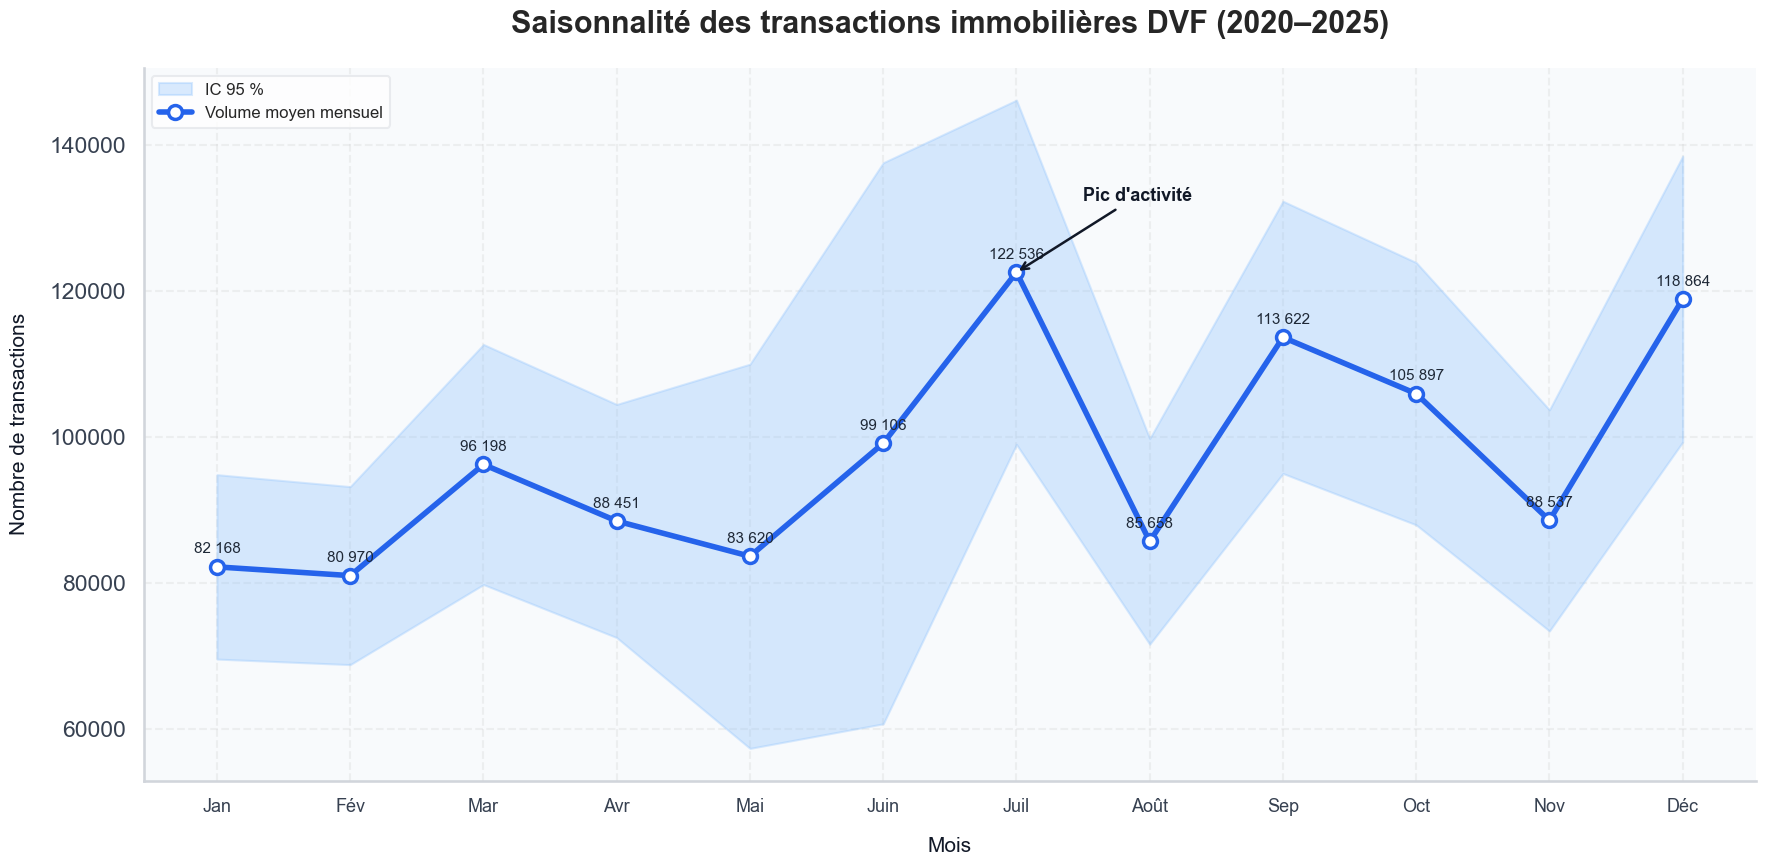

In [4]:
# ============================================================
# 5.1 Analyse des dynamiques temporelles et saisonnières
# Évolution mensuelle des volumes de transactions DVF
# Avec intervalles de confiance 95%
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# STYLE VISUEL PROFESSIONNEL
# ============================================================

sns.set_theme(style="whitegrid", context="talk")

plt.rcParams.update({
    "figure.figsize": (18, 9),
    "figure.facecolor": "white",
    "axes.facecolor": "#F8FAFC",
    "axes.edgecolor": "#D1D5DB",
    "axes.labelcolor": "#111827",
    "xtick.color": "#374151",
    "ytick.color": "#374151",
    "axes.titleweight": "bold",
    "font.family": "sans-serif"
})

# ============================================================
# PRÉPARATION DES DONNÉES
# ============================================================

# Conversion date
df["date_mutation"] = pd.to_datetime(df["date_mutation"])

# Sélection période 2020-2025
df = df[
    (df["annee"] >= 2020) &
    (df["annee"] <= 2025)
]

# ============================================================
# AGRÉGATION DES TRANSACTIONS PAR MOIS ET PAR ANNÉE
# ============================================================

monthly_transactions = (
    df.groupby(["annee", "mois"])
      .size()
      .reset_index(name="volume_transactions")
)

# ============================================================
# CALCUL MOYENNES + IC95
# ============================================================

monthly_stats = (
    monthly_transactions
    .groupby("mois")["volume_transactions"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

# Intervalle de confiance à 95 %
monthly_stats["ic95"] = (
    1.96
    * monthly_stats["std"]
    / np.sqrt(monthly_stats["count"])
)

monthly_stats["borne_inf"] = (
    monthly_stats["mean"]
    - monthly_stats["ic95"]
)

monthly_stats["borne_sup"] = (
    monthly_stats["mean"]
    + monthly_stats["ic95"]
)

# ============================================================
# LABELS DES MOIS
# ============================================================

mois_labels = [
    "Jan", "Fév", "Mar", "Avr",
    "Mai", "Juin", "Juil", "Août",
    "Sep", "Oct", "Nov", "Déc"
]

# ============================================================
# VISUALISATION
# ============================================================

fig, ax = plt.subplots()

# Couleurs modernes
line_color = "#2563EB"
shade_color = "#93C5FD"

# ------------------------------------------------------------
# BANDE DE CONFIANCE
# ------------------------------------------------------------

ax.fill_between(
    monthly_stats["mois"],
    monthly_stats["borne_inf"],
    monthly_stats["borne_sup"],
    color=shade_color,
    alpha=0.35,
    label="IC 95 %"
)

# ------------------------------------------------------------
# COURBE PRINCIPALE
# ------------------------------------------------------------

ax.plot(
    monthly_stats["mois"],
    monthly_stats["mean"],
    color=line_color,
    linewidth=4,
    marker="o",
    markersize=10,
    markerfacecolor="white",
    markeredgewidth=2.5,
    label="Volume moyen mensuel"
)

# ============================================================
# AJOUT DES VALEURS SUR LES POINTS
# ============================================================

for x, y in zip(monthly_stats["mois"], monthly_stats["mean"]):
    ax.text(
        x,
        y + monthly_stats["mean"].max() * 0.015,
        f"{int(y):,}".replace(",", " "),
        ha="center",
        fontsize=11,
        color="#1F2937"
    )

# ============================================================
# PERSONNALISATION
# ============================================================

ax.set_xticks(range(1, 13))
ax.set_xticklabels(mois_labels, fontsize=13)

ax.set_xlabel(
    "Mois",
    fontsize=15,
    labelpad=15
)

ax.set_ylabel(
    "Nombre de transactions",
    fontsize=15,
    labelpad=15
)

ax.set_title(
    "Saisonnalité des transactions immobilières DVF (2020–2025)",
    fontsize=22,
    pad=25
)

# Grille légère
ax.grid(
    linestyle="--",
    alpha=0.25
)

# Suppression bordures inutiles
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Légende premium
legend = ax.legend(
    frameon=True,
    fontsize=12,
    loc="upper left"
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("#E5E7EB")

# ============================================================
# ANNOTATION AUTOMATIQUE DU PIC
# ============================================================

peak_idx = monthly_stats["mean"].idxmax()

peak_month = monthly_stats.loc[peak_idx, "mois"]
peak_value = monthly_stats.loc[peak_idx, "mean"]

ax.annotate(
    "Pic d'activité",
    xy=(peak_month, peak_value),
    xytext=(peak_month + 0.5, peak_value * 1.08),
    fontsize=13,
    fontweight="bold",
    color="#111827",
    arrowprops=dict(
        arrowstyle="->",
        lw=1.8,
        color="#111827"
    )
)

plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# 5.2 Analyse des segments structurels : impact du neuf
# Boxplots notched + échelle logarithmique
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# STYLE PRO (cohérent avec 5.1)
# ============================================================

sns.set_theme(style="whitegrid", context="talk")

plt.rcParams.update({
    "figure.figsize": (14, 8),
    "figure.facecolor": "white",
    "axes.facecolor": "#F8FAFC",
    "axes.edgecolor": "#D1D5DB",
    "axes.labelcolor": "#111827",
    "xtick.color": "#374151",
    "ytick.color": "#374151",
    "axes.titleweight": "bold",
    "font.family": "sans-serif"
})

# ============================================================
# NETTOYAGE DONNÉES
# ============================================================

df_52 = df.copy()

# Garder uniquement les valeurs valides
df_52 = df_52.dropna(subset=["valeur_fonciere", "is_neuf"])

# Filtrage valeurs aberrantes (important pour DVF)
df_52 = df_52[df_52["valeur_fonciere"] > 0]

# Log transformation (on garde aussi l'échelle brute pour interprétation)
df_52["log_valeur_fonciere"] = np.log10(df_52["valeur_fonciere"])

# Mapping lisible
df_52["statut_bien"] = df_52["is_neuf"].map({
    0: "Ancien",
    1: "Neuf"
})

# ============================================================
# VISUALISATION
# ============================================================

fig, ax = plt.subplots()

# Palette premium
palette = {
    "Ancien": "#2563EB",
    "Neuf": "#F97316"
}

# ------------------------------------------------------------
# BOXPLOT NOTCHED
# ------------------------------------------------------------

sns.boxplot(
    data=df_52,
    x="statut_bien",
    y="log_valeur_fonciere",
    ax=ax,
    palette=palette,
    width=0.5,
    linewidth=2,
    notch=True,
    showfliers=False  # important pour lisibilité DVF
)

# ------------------------------------------------------------
# JITTER (points individuels légers pour densité)
# ------------------------------------------------------------

sns.stripplot(
    data=df_52.sample(min(len(df_52), 5000), random_state=42),
    x="statut_bien",
    y="log_valeur_fonciere",
    ax=ax,
    color="black",
    alpha=0.15,
    size=2,
    jitter=0.25
)

# ============================================================
# PERSONNALISATION AXES
# ============================================================

ax.set_title(
    "Impact du statut neuf sur la valeur foncière (DVF)",
    fontsize=20,
    pad=20
)

ax.set_xlabel("")
ax.set_ylabel("log10(Valeur foncière)", fontsize=14)

# ============================================================
# AJOUT INTERPRÉTATION DIRECTE (ANNOTATION)
# ============================================================

median_old = df_52[df_52["is_neuf"] == 0]["log_valeur_fonciere"].median()
median_new = df_52[df_52["is_neuf"] == 1]["log_valeur_fonciere"].median()

ax.annotate(
    "Différence structurelle visible\nentre ancien et neuf",
    xy=(0.5, max(median_old, median_new)),
    xytext=(0.6, max(median_old, median_new) + 0.4),
    arrowprops=dict(arrowstyle="->", lw=1.5, color="#111827"),
    fontsize=12,
    color="#111827"
)

# ============================================================
# GRILLE & FINITIONS
# ============================================================

ax.grid(True, linestyle="--", alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

KeyError: ['is_neuf']

In [6]:
df.head()

,id_mutation,date_mutation,annee,mois,nature_mutation,valeur_fonciere,surface_reelle_bati,prix_m2,type_local,nombre_pieces_principales,...,code_departement,code_commune,nom_commune,code_postal,adresse_numero,adresse_nom_voie,adresse_complete,longitude,latitude,coordonnees_disponibles
0,2020-6,2020-07-02,2020,7,Vente,77000.0,115.0,669.565217,Maison,2.0,...,01,01130,Bresse Vallons,1340.0,347.0,RTE DE JALAMONDE,347.0 RTE DE JALAMONDE 1340.0 Bresse Vallons,5.198842,46.308020,True
1,2020-8,2020-07-01,2020,7,Vente,279000.0,122.0,2286.885246,Maison,5.0,...,01,01451,Viriat,1440.0,1084.0,RTE DE CRANGEAT,1084.0 RTE DE CRANGEAT 1440.0 Viriat,5.215936,46.264536,True
2,2020-9,2020-07-02,2020,7,Vente,177650.0,80.0,2220.625000,Maison,3.0,...,01,01364,Saint-Jean-sur-Reyssouze,1560.0,192.0,RUE DE MONTFLEURY,192.0 RUE DE MONTFLEURY 1560.0 Saint-Jean-sur-...,5.061938,46.396034,True
3,2020-11,2020-07-03,2020,7,Vente,169111.0,86.0,1966.406977,Maison,4.0,...,01,01053,Bourg-en-Bresse,1000.0,71.0,RUE BRICHEMER,71.0 RUE BRICHEMER 1000.0 Bourg-en-Bresse,5.251962,46.212201,True
4,2020-12,2020-07-02,2020,7,Vente,190000.0,114.0,1666.666667,Maison,4.0,...,01,01177,Grand-Corent,1250.0,5062.0,EN BOURRAVIER,5062.0 EN BOURRAVIER 1250.0 Grand-Corent,5.428764,46.200750,True


C:\Users\carine\AppData\Local\Temp\ipykernel_8804\3847098550.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


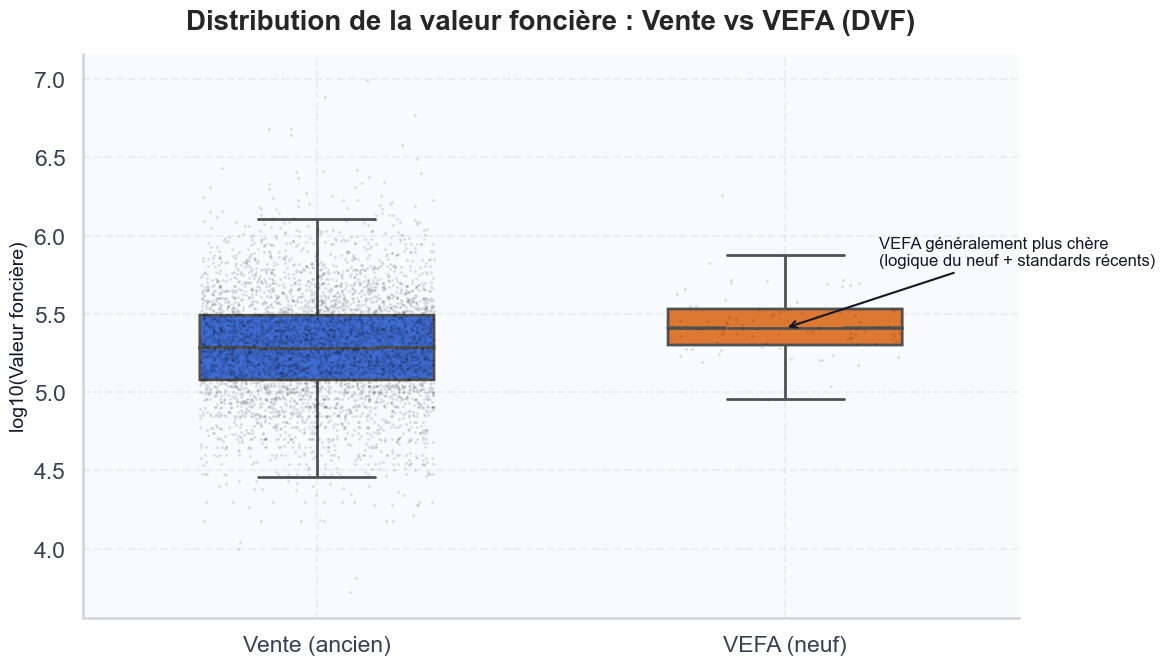

In [8]:
# ============================================================
# 5.2 SEGMENTATION : Vente vs VEFA
# Boxplots professionnels + log scale
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# STYLE PRO (cohérent avec ton rendu)
# ============================================================

sns.set_theme(style="whitegrid", context="talk")

plt.rcParams.update({
    "figure.figsize": (12, 7),
    "figure.facecolor": "white",
    "axes.facecolor": "#F8FAFC",
    "axes.edgecolor": "#D1D5DB",
    "axes.labelcolor": "#111827",
    "xtick.color": "#374151",
    "ytick.color": "#374151",
    "axes.titleweight": "bold",
    "font.family": "sans-serif"
})

# ============================================================
# PRÉPARATION DES DONNÉES
# ============================================================

df_52 = df.copy()

df_52 = df_52.dropna(subset=["valeur_fonciere", "nature_mutation"])
df_52 = df_52[df_52["valeur_fonciere"] > 0]

# ============================================================
# FILTRE UNIQUEMENT 2 CATÉGORIES
# ============================================================

df_52 = df_52[
    df_52["nature_mutation"].isin([
        "Vente",
        "Vente en l'état futur d'achèvement"
    ])
].copy()

# Renommage propre pour le graphique
df_52["segment"] = df_52["nature_mutation"].replace({
    "Vente": "Vente (ancien)",
    "Vente en l'état futur d'achèvement": "VEFA (neuf)"
})

# Log transformation (essentiel DVF)
df_52["log_valeur_fonciere"] = np.log10(df_52["valeur_fonciere"])

# ============================================================
# ORDRE DES CATÉGORIES
# ============================================================

order = ["Vente (ancien)", "VEFA (neuf)"]

# ============================================================
# VISUALISATION
# ============================================================

fig, ax = plt.subplots()

palette = {
    "Vente (ancien)": "#2563EB",   # bleu
    "VEFA (neuf)": "#F97316"       # orange
}

# ------------------------------------------------------------
# BOXPLOT NOTCHED
# ------------------------------------------------------------

sns.boxplot(
    data=df_52,
    x="segment",
    y="log_valeur_fonciere",
    order=order,
    ax=ax,
    palette=palette,
    width=0.5,
    notch=True,
    showfliers=False,
    linewidth=2
)

# ------------------------------------------------------------
# POINTS (densité légère pour VEFA faible)
# ------------------------------------------------------------

sns.stripplot(
    data=df_52.sample(min(len(df_52), 5000), random_state=42),
    x="segment",
    y="log_valeur_fonciere",
    order=order,
    ax=ax,
    color="black",
    alpha=0.12,
    size=2,
    jitter=0.25
)

# ============================================================
# TITRE & LABELS
# ============================================================

ax.set_title(
    "Distribution de la valeur foncière : Vente vs VEFA (DVF)",
    fontsize=20,
    pad=18
)

ax.set_xlabel("")
ax.set_ylabel("log10(Valeur foncière)", fontsize=14)

# ============================================================
# ANNOTATION INTERPRÉTATIVE
# ============================================================

medians = df_52.groupby("segment")["log_valeur_fonciere"].median()

ax.annotate(
    "VEFA généralement plus chère\n(logique du neuf + standards récents)",
    xy=(1, medians["VEFA (neuf)"]),
    xytext=(1.2, medians["VEFA (neuf)"] + 0.4),
    arrowprops=dict(arrowstyle="->", lw=1.5, color="#111827"),
    fontsize=12,
    color="#111827"
)

# ============================================================
# FINITIONS VISUELLES
# ============================================================

ax.grid(True, linestyle="--", alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [10]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 11.1 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.6 MB 39.9 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 27.8 MB/s  0:00:00

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- --------------


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


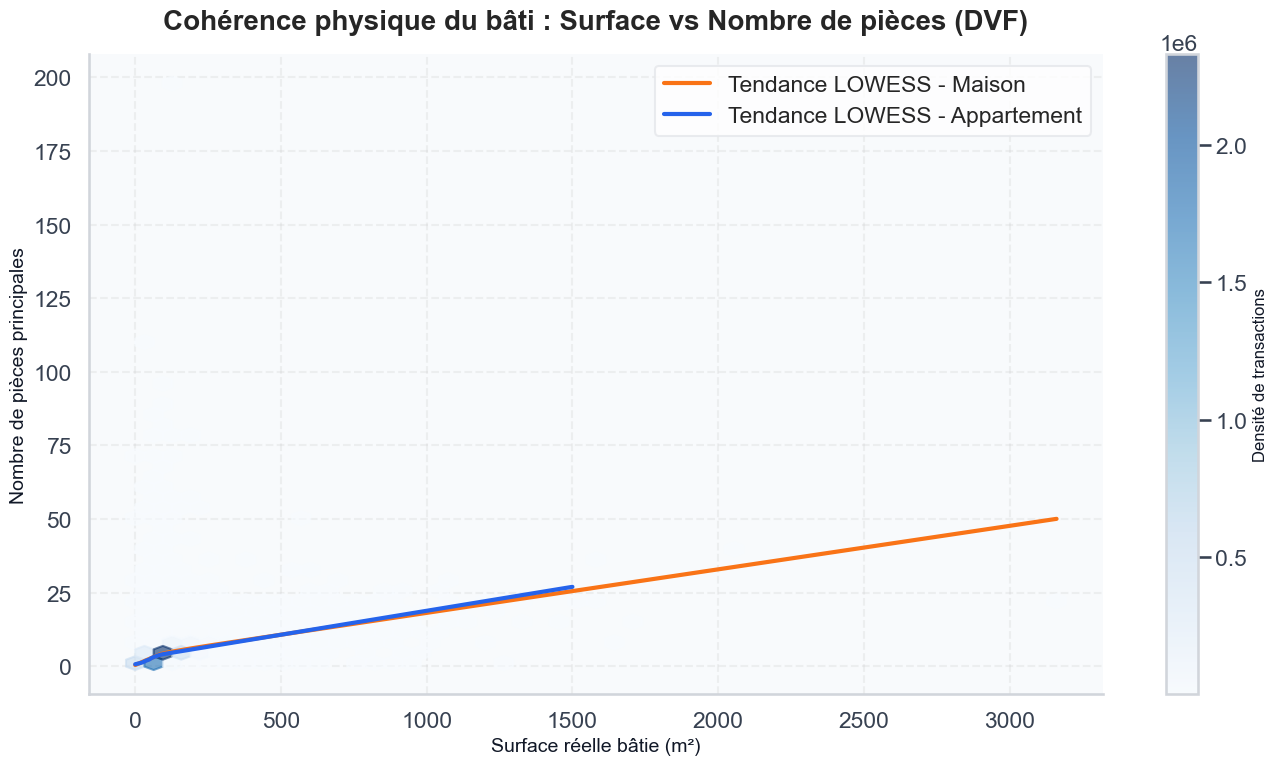

In [11]:
# ============================================================
# 5.3 VALIDATION COHÉRENCE PHYSIQUE DU BÂTI
# Surface réelle vs nombre de pièces
# Hexbin + LOWESS par type de bien
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.nonparametric.smoothers_lowess import lowess

# ============================================================
# STYLE PRO (cohérent mémoire)
# ============================================================

sns.set_theme(style="whitegrid", context="talk")

plt.rcParams.update({
    "figure.figsize": (14, 8),
    "figure.facecolor": "white",
    "axes.facecolor": "#F8FAFC",
    "axes.edgecolor": "#D1D5DB",
    "axes.labelcolor": "#111827",
    "xtick.color": "#374151",
    "ytick.color": "#374151",
    "axes.titleweight": "bold",
    "font.family": "sans-serif"
})

# ============================================================
# PRÉPARATION DONNÉES
# ============================================================

df_53 = df.copy()

df_53 = df_53.dropna(subset=["surface_reelle_bati", "nombre_pieces_principales", "type_local"])

df_53 = df_53[
    (df_53["surface_reelle_bati"] > 0) &
    (df_53["nombre_pieces_principales"] > 0)
]

# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots()

# ------------------------------------------------------------
# HEXBIN GLOBAL (densité structurelle)
# ------------------------------------------------------------

hb = ax.hexbin(
    df_53["surface_reelle_bati"],
    df_53["nombre_pieces_principales"],
    gridsize=50,
    cmap="Blues",
    mincnt=1,
    alpha=0.6
)

cbar = plt.colorbar(hb, ax=ax)
cbar.set_label("Densité de transactions", fontsize=12)

# ============================================================
# LOWESS PAR TYPE DE BIEN
# ============================================================

colors = {
    "Maison": "#F97316",
    "Appartement": "#2563EB"
}

for t in ["Maison", "Appartement"]:
    
    subset = df_53[df_53["type_local"] == t].copy()
    
    if len(subset) < 50:
        continue

    # Tri pour LOWESS stable
    subset = subset.sort_values("surface_reelle_bati")

    smoothed = lowess(
        subset["nombre_pieces_principales"],
        subset["surface_reelle_bati"],
        frac=0.3
    )

    ax.plot(
        smoothed[:, 0],
        smoothed[:, 1],
        color=colors.get(t, "black"),
        linewidth=3,
        label=f"Tendance LOWESS - {t}"
    )

# ============================================================
# TITRE & LABELS
# ============================================================

ax.set_title(
    "Cohérence physique du bâti : Surface vs Nombre de pièces (DVF)",
    fontsize=20,
    pad=18
)

ax.set_xlabel("Surface réelle bâtie (m²)", fontsize=14)
ax.set_ylabel("Nombre de pièces principales", fontsize=14)

# ============================================================
# FINITIONS VISUELLES
# ============================================================

ax.grid(True, linestyle="--", alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=True, facecolor="white", edgecolor="#E5E7EB")

plt.tight_layout()
plt.show()

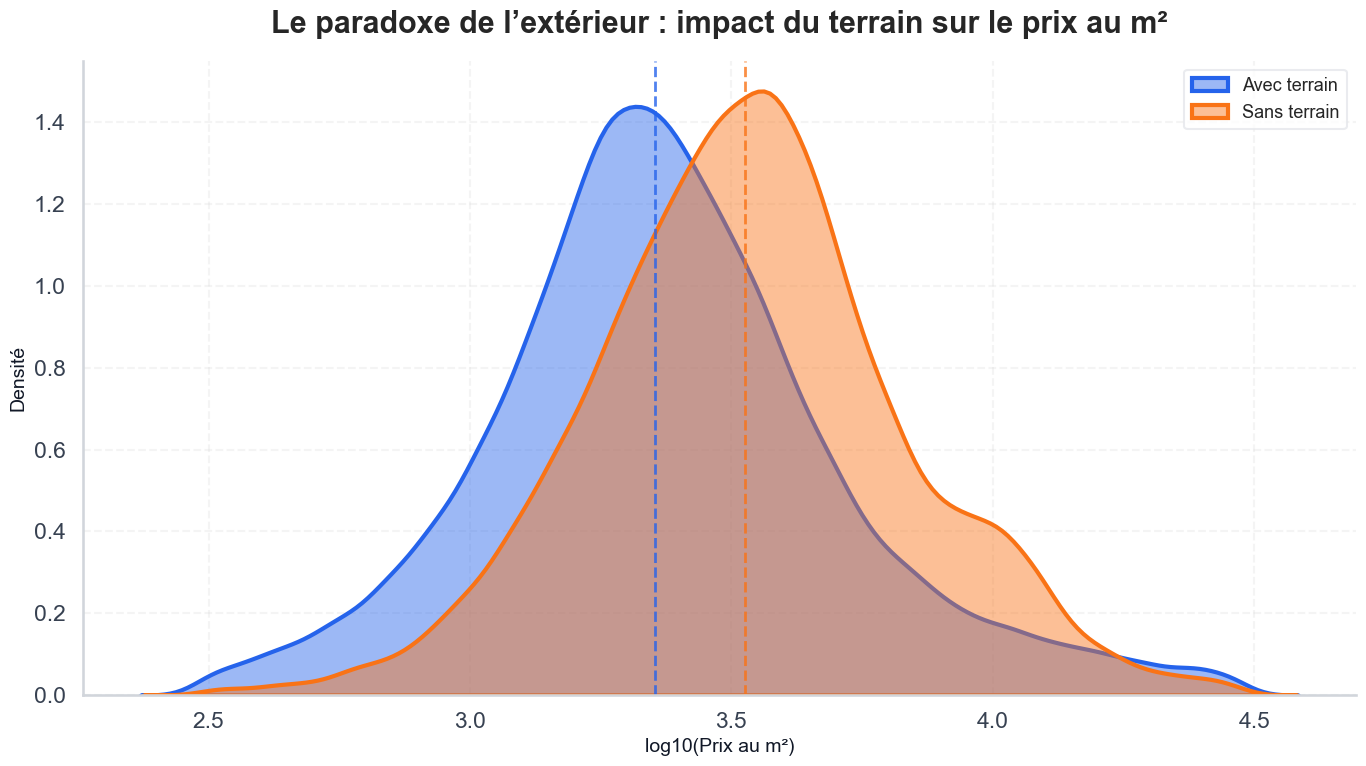

In [15]:
# ============================================================
# 5.4 LE PARADOXE DE L'EXTÉRIEUR
# Joyplot / Ridge Plot corrigé
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# STYLE PREMIUM
# ============================================================

sns.set_theme(style="white", context="talk")

plt.rcParams.update({
    "figure.figsize": (14, 8),
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#D1D5DB",
    "axes.labelcolor": "#111827",
    "xtick.color": "#374151",
    "ytick.color": "#374151",
    "font.family": "sans-serif"
})

# ============================================================
# VARIABLES UTILES UNIQUEMENT
# ============================================================

terrain_col = "surface_terrain"  # adapte si besoin

df_54 = df[
    [terrain_col, "prix_m2"]
].copy()

# ============================================================
# CONSTRUCTION ROBUSTE DE has_terrain
# ============================================================

# IMPORTANT :
# NaN = pas de terrain

df_54[terrain_col] = df_54[terrain_col].fillna(0)

df_54["has_terrain"] = np.where(
    df_54[terrain_col] > 0,
    "Avec terrain",
    "Sans terrain"
)

# ============================================================
# FILTRAGE DVF
# ============================================================

df_54 = df_54.dropna(subset=["prix_m2"])

df_54 = df_54[
    (df_54["prix_m2"] > 100) &
    (df_54["prix_m2"] < 50000)
]

# ============================================================
# ÉCHANTILLONNAGE
# ============================================================

MAX_SAMPLE = 120000

if len(df_54) > MAX_SAMPLE:
    df_54 = df_54.sample(
        MAX_SAMPLE,
        random_state=42
    )

# ============================================================
# LOG TRANSFORMATION
# ============================================================

df_54["log_prix_m2"] = np.log10(df_54["prix_m2"])

# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots()

colors = {
    "Avec terrain": "#2563EB",
    "Sans terrain": "#F97316"
}

# ============================================================
# KDE SUPERPOSÉES
# ============================================================

for label in ["Avec terrain", "Sans terrain"]:

    subset = df_54[
        df_54["has_terrain"] == label
    ]

    sns.kdeplot(
        data=subset,
        x="log_prix_m2",
        fill=True,
        alpha=0.45,
        linewidth=3,
        color=colors[label],
        label=label,
        ax=ax
    )

    # Médiane
    median = subset["log_prix_m2"].median()

    ax.axvline(
        median,
        linestyle="--",
        linewidth=2,
        color=colors[label],
        alpha=0.8
    )

# ============================================================
# TITRE & LABELS
# ============================================================

ax.set_title(
    "Le paradoxe de l’extérieur : impact du terrain sur le prix au m²",
    fontsize=22,
    pad=20,
    fontweight="bold"
)

ax.set_xlabel(
    "log10(Prix au m²)",
    fontsize=14
)

ax.set_ylabel("Densité", fontsize=14)

# ============================================================
# LÉGENDE PREMIUM
# ============================================================

legend = ax.legend(
    frameon=True,
    fontsize=13
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("#E5E7EB")

# ============================================================
# FINITIONS
# ============================================================

ax.grid(True, linestyle="--", alpha=0.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

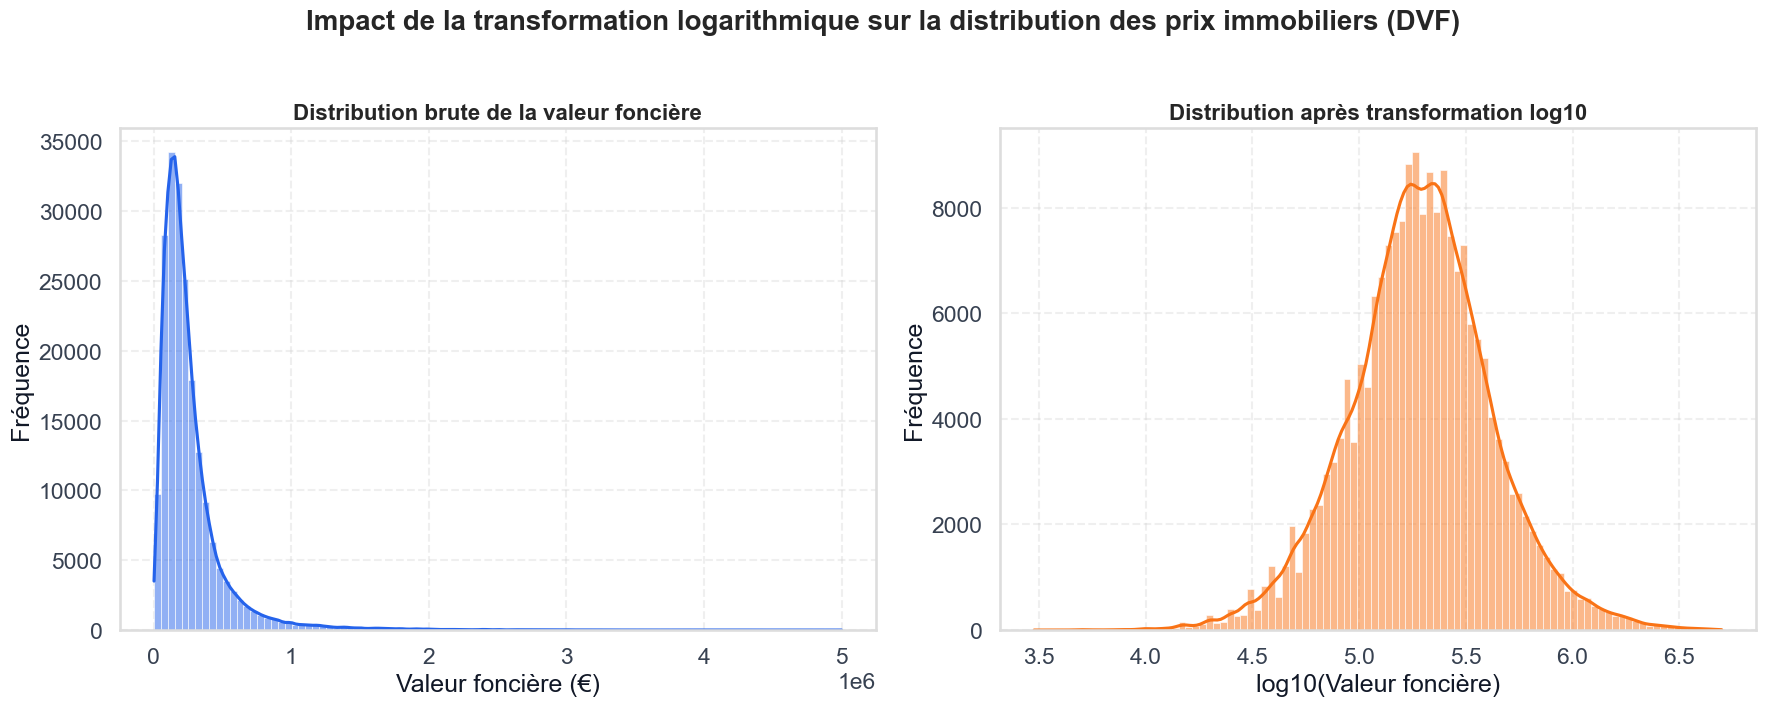

In [21]:
# ============================================================
# DISTRIBUTION BRUTE vs TRANSFORMATION LOG
# Visualisation comparative professionnelle
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# STYLE PREMIUM
# ============================================================

sns.set_theme(style="whitegrid", context="talk")

plt.rcParams.update({
    "figure.figsize": (16, 7),
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#DDDDDD",
    "axes.labelcolor": "#111827",
    "xtick.color": "#374151",
    "ytick.color": "#374151",
    "font.family": "sans-serif"
})

# ============================================================
# DONNÉES
# ============================================================

df_plot = df[["valeur_fonciere"]].dropna()

# Filtrage robuste DVF (évite outliers extrêmes)
df_plot = df_plot[df_plot["valeur_fonciere"] > 0]
df_plot = df_plot[df_plot["valeur_fonciere"] < 5_000_000]

# Échantillonnage (stabilité mémoire + rendu identique visuellement)
MAX_SAMPLE = 200000

if len(df_plot) > MAX_SAMPLE:
    df_plot = df_plot.sample(MAX_SAMPLE, random_state=42)

# Transformation log
df_plot["log_valeur"] = np.log10(df_plot["valeur_fonciere"])

# ============================================================
# FIGURE CÔTE À CÔTE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ============================================================
# GAUCHE : DISTRIBUTION BRUTE
# ============================================================

sns.histplot(
    df_plot["valeur_fonciere"],
    bins=100,
    kde=True,
    color="#2563EB",
    ax=axes[0]
)

axes[0].set_title(
    "Distribution brute de la valeur foncière",
    fontsize=16,
    fontweight="bold"
)

axes[0].set_xlabel("Valeur foncière (€)")
axes[0].set_ylabel("Fréquence")

axes[0].grid(True, linestyle="--", alpha=0.3)

# ============================================================
# DROITE : DISTRIBUTION LOG
# ============================================================

sns.histplot(
    df_plot["log_valeur"],
    bins=100,
    kde=True,
    color="#F97316",
    ax=axes[1]
)

axes[1].set_title(
    "Distribution après transformation log10",
    fontsize=16,
    fontweight="bold"
)

axes[1].set_xlabel("log10(Valeur foncière)")
axes[1].set_ylabel("Fréquence")

axes[1].grid(True, linestyle="--", alpha=0.3)

# ============================================================
# TITRE GLOBAL
# ============================================================

fig.suptitle(
    "Impact de la transformation logarithmique sur la distribution des prix immobiliers (DVF)",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

# ============================================================
# FINITIONS
# ============================================================

plt.tight_layout()
plt.show()

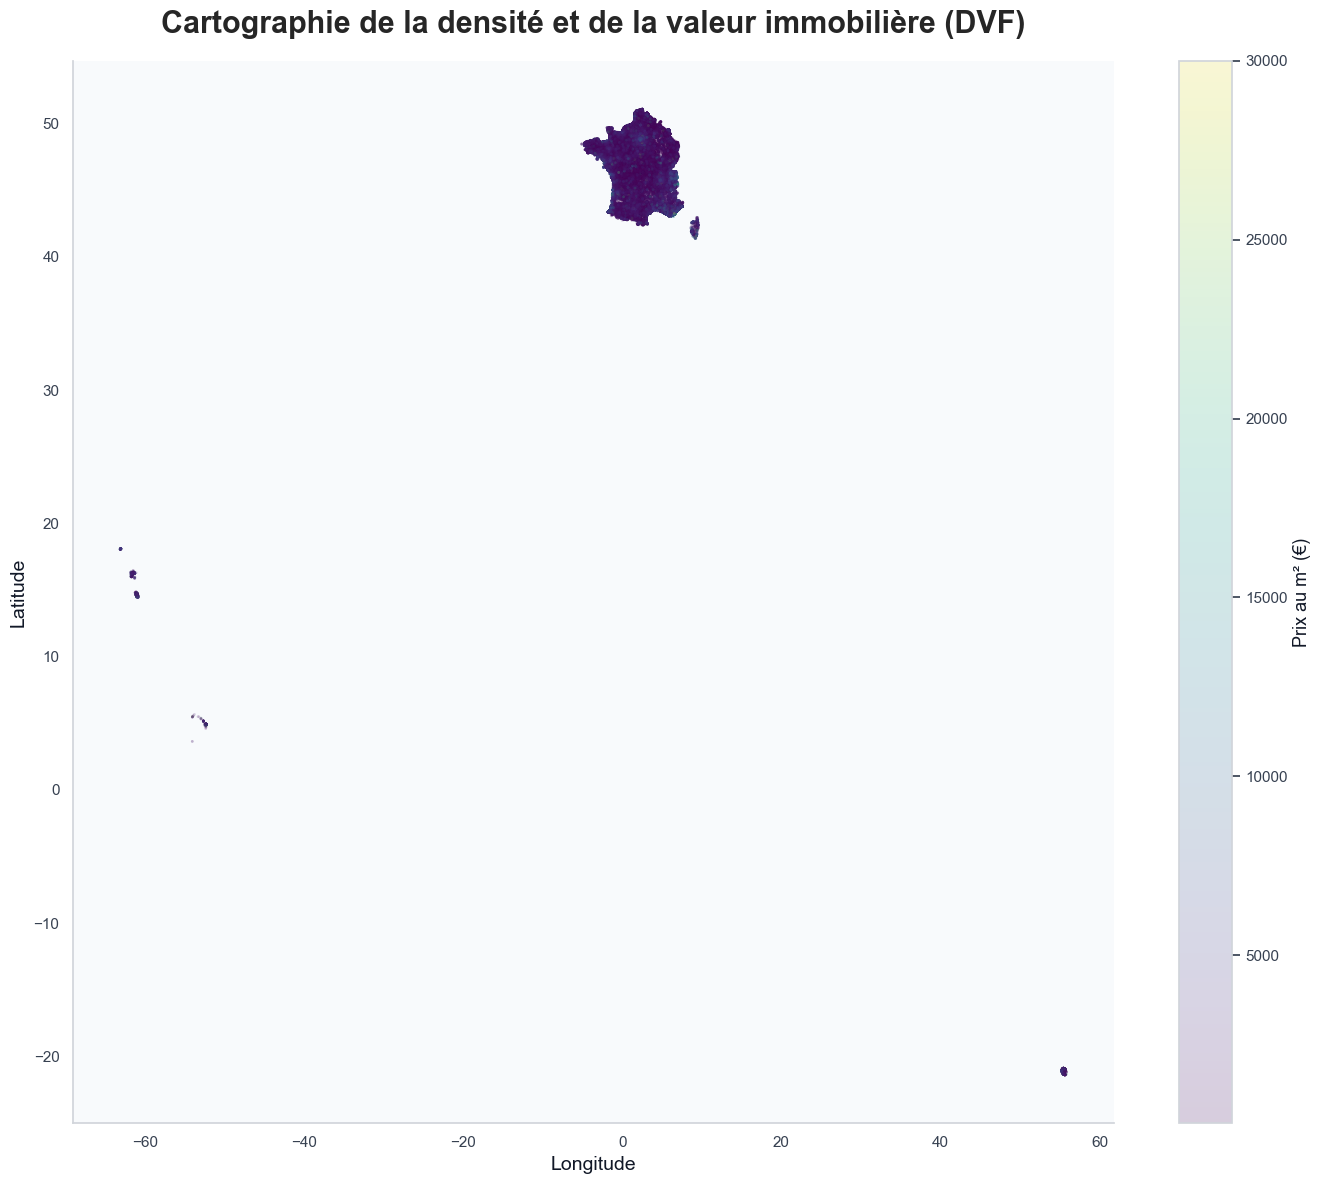

In [16]:
# ============================================================
# CARTOGRAPHIE DE LA DENSITÉ ET DE LA VALEUR
# Scatter géospatial haute résolution
# Couleur = prix au m²
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# STYLE PREMIUM
# ============================================================

sns.set_theme(style="white")

plt.rcParams.update({
    "figure.figsize": (14, 12),
    "figure.facecolor": "white",
    "axes.facecolor": "#F8FAFC",
    "axes.edgecolor": "#D1D5DB",
    "axes.labelcolor": "#111827",
    "xtick.color": "#374151",
    "ytick.color": "#374151",
    "font.family": "sans-serif"
})

# ============================================================
# SÉLECTION VARIABLES UTILES UNIQUEMENT
# ============================================================

df_map = df[
    ["longitude", "latitude", "prix_m2"]
].dropna()

# ============================================================
# FILTRAGE ROBUSTE DVF
# ============================================================

df_map = df_map[
    (df_map["prix_m2"] > 100) &
    (df_map["prix_m2"] < 50000)
]

# ============================================================
# ÉCHANTILLONNAGE
# (sinon 5M points = inutilisable)
# ============================================================

MAX_SAMPLE = 200000

if len(df_map) > MAX_SAMPLE:
    df_map = df_map.sample(
        MAX_SAMPLE,
        random_state=42
    )

# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots()

# ============================================================
# SCATTER GÉOSPATIAL
# ============================================================

scatter = ax.scatter(
    df_map["longitude"],
    df_map["latitude"],
    
    c=df_map["prix_m2"],
    
    cmap="viridis",
    
    s=4,
    
    alpha=0.18,
    
    linewidths=0
)

# ============================================================
# COLORBAR
# ============================================================

cbar = plt.colorbar(scatter)

cbar.set_label(
    "Prix au m² (€)",
    fontsize=13
)

# ============================================================
# TITRE
# ============================================================

ax.set_title(
    "Cartographie de la densité et de la valeur immobilière (DVF)",
    fontsize=22,
    pad=20,
    fontweight="bold"
)

# ============================================================
# LABELS
# ============================================================

ax.set_xlabel("Longitude", fontsize=14)
ax.set_ylabel("Latitude", fontsize=14)

# ============================================================
# FINITIONS
# ============================================================

ax.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

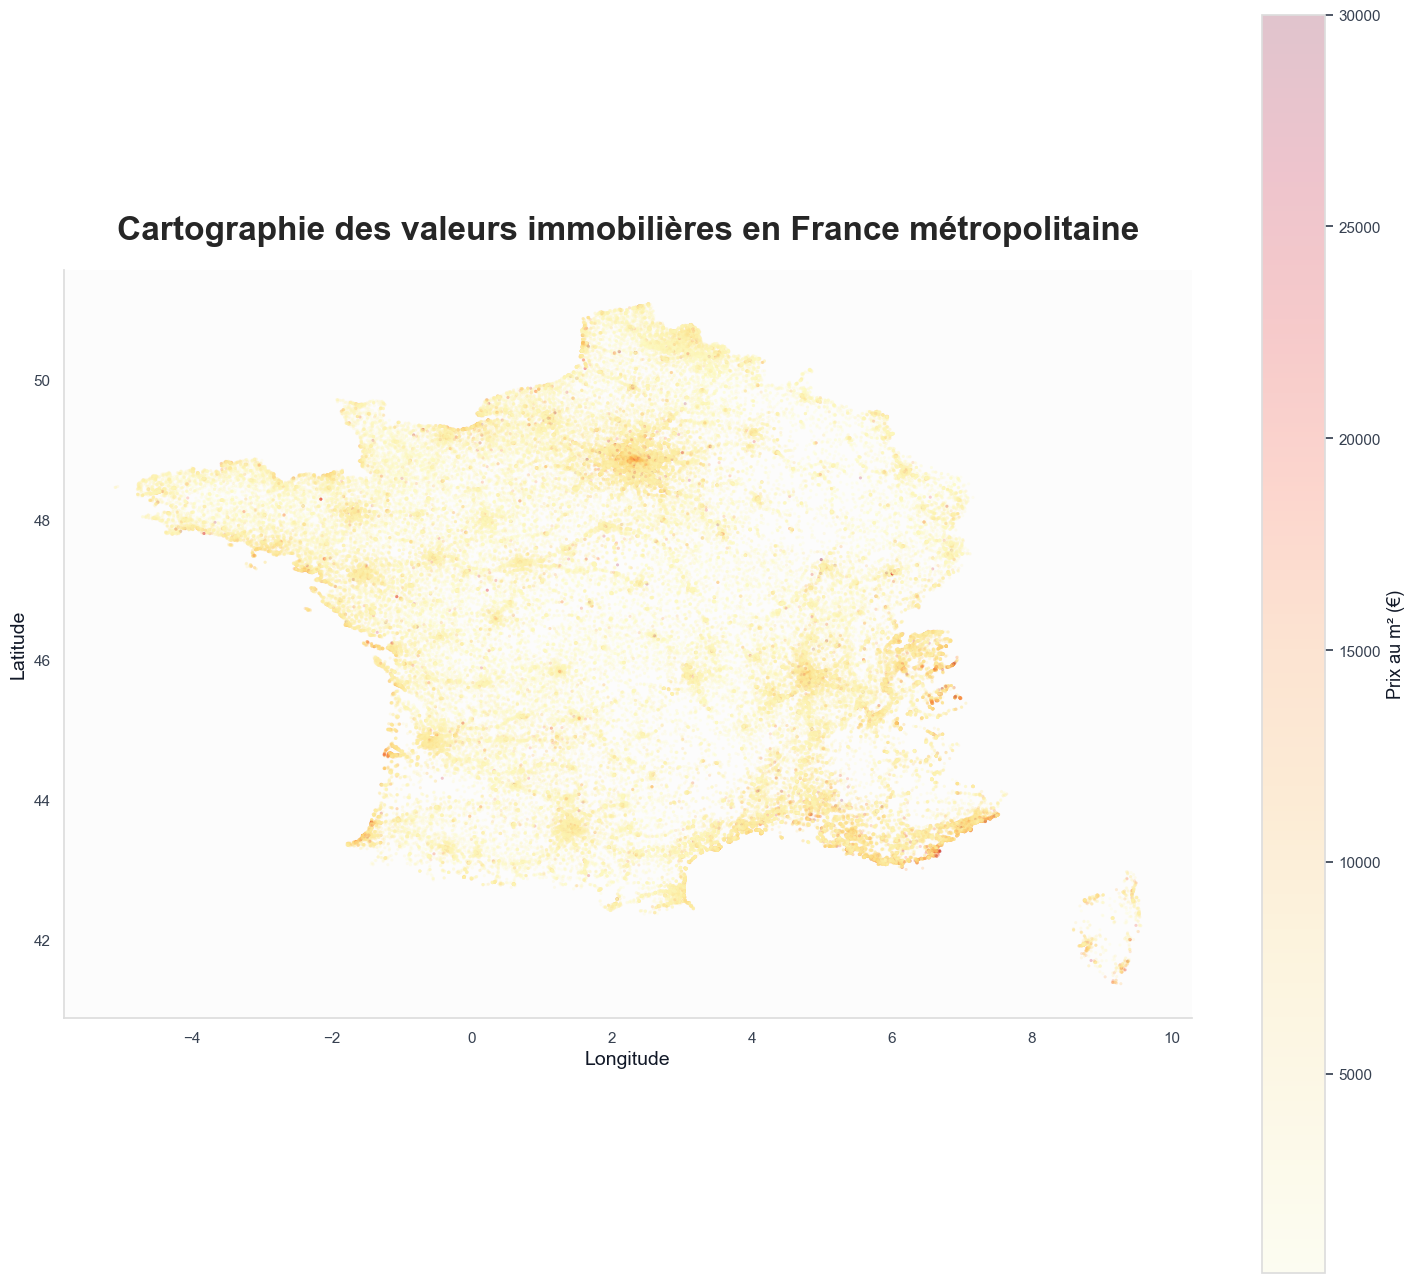

In [17]:
# ============================================================
# CARTOGRAPHIE DE LA VALEUR IMMOBILIÈRE — FRANCE MÉTROPOLITAINE + CORSE
# Scatter géospatial premium (palette chaude)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# STYLE VISUEL
# ============================================================

sns.set_theme(style="white")

plt.rcParams.update({
    "figure.figsize": (15, 13),
    "figure.facecolor": "white",
    "axes.facecolor": "#FCFCFC",
    "axes.edgecolor": "#DDDDDD",
    "axes.labelcolor": "#111827",
    "xtick.color": "#374151",
    "ytick.color": "#374151",
    "font.family": "sans-serif"
})

# ============================================================
# VARIABLES NÉCESSAIRES UNIQUEMENT
# ============================================================

df_map = df[
    ["longitude", "latitude", "prix_m2"]
].dropna()

# ============================================================
# FILTRAGE FRANCE MÉTROPOLITAINE + CORSE
# ============================================================

# Bounding box approximative :
# longitude : -5.5 → 10
# latitude  : 41 → 51.5

df_map = df_map[
    (df_map["longitude"] >= -5.5) &
    (df_map["longitude"] <= 10) &
    (df_map["latitude"] >= 41) &
    (df_map["latitude"] <= 51.5)
]

# ============================================================
# FILTRAGE PRIX DVF
# ============================================================

df_map = df_map[
    (df_map["prix_m2"] > 100) &
    (df_map["prix_m2"] < 50000)
]

# ============================================================
# ÉCHANTILLONNAGE (important DVF)
# ============================================================

MAX_SAMPLE = 220000

if len(df_map) > MAX_SAMPLE:
    df_map = df_map.sample(
        MAX_SAMPLE,
        random_state=42
    )

# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots()

# ============================================================
# SCATTER GÉOSPATIAL
# ============================================================

scatter = ax.scatter(
    df_map["longitude"],
    df_map["latitude"],

    c=df_map["prix_m2"],

    # Palette chaude premium
    cmap="YlOrRd",

    s=5,

    alpha=0.22,

    linewidths=0
)

# ============================================================
# COLORBAR
# ============================================================

cbar = plt.colorbar(scatter)

cbar.set_label(
    "Prix au m² (€)",
    fontsize=13
)

# ============================================================
# TITRE
# ============================================================

ax.set_title(
    "Cartographie des valeurs immobilières en France métropolitaine",
    fontsize=24,
    pad=22,
    fontweight="bold"
)

# ============================================================
# LABELS
# ============================================================

ax.set_xlabel("Longitude", fontsize=14)
ax.set_ylabel("Latitude", fontsize=14)

# ============================================================
# PROPORTIONS GÉOGRAPHIQUES
# ============================================================

ax.set_aspect('equal')

# ============================================================
# FINITIONS
# ============================================================

ax.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# TOP 10 COMMUNES
# Prix au m² + volume de transactions
# Double axe (bar + line)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# STYLE PREMIUM
# ============================================================

sns.set_theme(style="whitegrid", context="talk")

plt.rcParams.update({
    "figure.figsize": (16, 8),
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#DDDDDD",
    "axes.labelcolor": "#111827",
    "xtick.color": "#374151",
    "ytick.color": "#374151",
    "font.family": "sans-serif"
})

# ============================================================
# AGRÉGATION PAR COMMUNE
# ============================================================

df_top = df[
    ["nom_commune", "prix_m2"]
].dropna()

df_top = df_top[
    (df_top["prix_m2"] > 100) &
    (df_top["prix_m2"] < 50000)
]

agg = df_top.groupby("nom_commune").agg(
    prix_m2_median=("prix_m2", "median"),
    volume=("prix_m2", "size")
).reset_index()

# ============================================================
# TOP 10 PAR PRIX MÉDIAN
# ============================================================

top10 = agg.sort_values(
    "prix_m2_median",
    ascending=False
).head(10)

# ============================================================
# FIGURE DOUBLE AXE
# ============================================================

fig, ax1 = plt.subplots()

# ------------------------------------------------------------
# BARPLOT : prix au m²
# ------------------------------------------------------------

bars = ax1.bar(
    top10["nom_commune"],
    top10["prix_m2_median"],
    color="#2563EB",
    alpha=0.85,
    label="Prix médian au m²"
)

ax1.set_ylabel("Prix médian au m² (€)", color="#2563EB")
ax1.tick_params(axis="y", labelcolor="#2563EB")

# rotation labels
plt.xticks(rotation=45, ha="right")

# ------------------------------------------------------------
# AXE 2 : volume transactions
# ------------------------------------------------------------

ax2 = ax1.twinx()

ax2.plot(
    top10["nom_commune"],
    top10["volume"],
    color="#F97316",
    marker="o",
    linewidth=3,
    label="Volume de transactions"
)

ax2.set_ylabel("Volume de transactions", color="#F97316")
ax2.tick_params(axis="y", labelcolor="#F97316")

# ============================================================
# TITRE
# ============================================================

plt.title(
    "Top 10 des communes les plus chères (prix/m² vs volume de transactions)",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# ============================================================
# GRILLE & FINITIONS
# ============================================================

ax1.grid(True, linestyle="--", alpha=0.25)

ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

plt.tight_layout()
plt.show()

: 

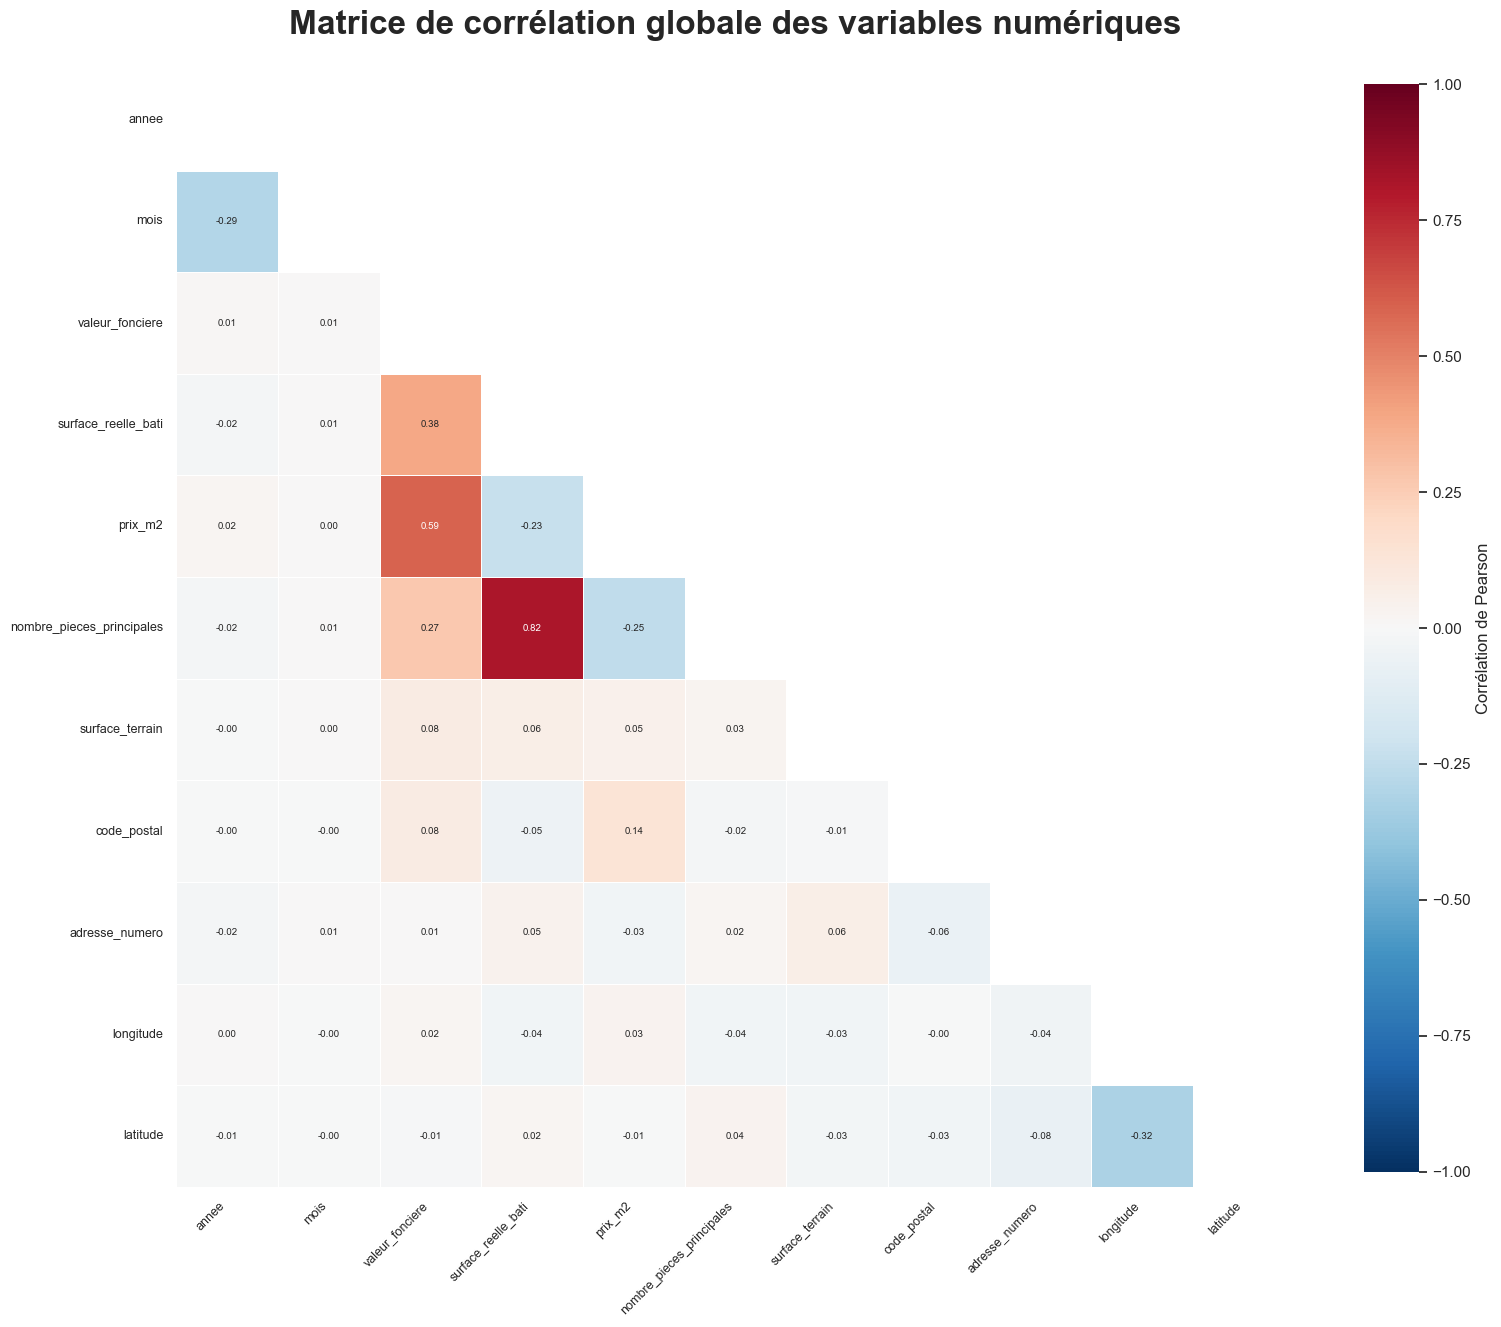

In [20]:
# ============================================================
# MATRICE DE CORRÉLATION GLOBALE
# Version optimisée mémoire + rendu carré
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# STYLE PREMIUM
# ============================================================

sns.set_theme(style="white")

plt.rcParams.update({
    "figure.figsize": (16, 16),
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.family": "sans-serif"
})

# ============================================================
# VARIABLES NUMÉRIQUES UNIQUEMENT
# (sans copy -> économise énormément de RAM)
# ============================================================

corr_df = df.select_dtypes(
    include=np.number
)

# ============================================================
# ÉCHANTILLONNAGE
# (très important sur DVF)
# ============================================================

MAX_SAMPLE = 150000

if len(corr_df) > MAX_SAMPLE:
    corr_df = corr_df.sample(
        MAX_SAMPLE,
        random_state=42
    )

# ============================================================
# SUPPRESSION VARIABLES CONSTANTES
# ============================================================

corr_df = corr_df.loc[
    :,
    corr_df.nunique() > 1
]

# ============================================================
# MATRICE DE CORRÉLATION
# ============================================================

corr_matrix = corr_df.corr(
    method="pearson",
    numeric_only=True
)

# ============================================================
# MASQUE TRIANGLE SUPÉRIEUR
# ============================================================

mask = np.triu(
    np.ones_like(corr_matrix, dtype=bool)
)

# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(16, 16))

# ============================================================
# HEATMAP
# ============================================================

sns.heatmap(
    corr_matrix,

    mask=mask,

    cmap="RdBu_r",

    vmin=-1,
    vmax=1,
    center=0,

    square=True,

    linewidths=0.7,
    linecolor="white",

    annot=True,
    fmt=".2f",

    annot_kws={
        "size": 7
    },

    cbar_kws={
        "shrink": 0.7,
        "label": "Corrélation de Pearson"
    },

    ax=ax
)

# ============================================================
# TITRE
# ============================================================

ax.set_title(
    "Matrice de corrélation globale des variables numériques",
    fontsize=24,
    pad=25,
    fontweight="bold"
)

# ============================================================
# LABELS
# ============================================================

plt.xticks(
    rotation=45,
    ha="right",
    fontsize=9
)

plt.yticks(
    rotation=0,
    fontsize=9
)

# ============================================================
# FINITIONS
# ============================================================

ax.set_facecolor("white")

plt.tight_layout()

plt.show()